# Vertical Profiles: CESM3 / MOM6 experiment comparison

Regional **vertical profiles** of temperature, salinity, and potential
density ($\sigma_2$), extending the horizontal (surface / 250 m) regional
bias diagnostics in `regional_biases.ipynb` with the full depth dimension.
A simplified set of five basin-scale regions is used throughout (see
Section 1). The shared `Experiment` class lives in `experiment.py` so it
can be reused across notebooks.

**Experiments compared**

| name | mode | data folder |
|------|------|-------------|
| `CTRL` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0_uANN_1.0` | coupled | `data/coupled_55years` |
| `forced_CTRL` | forced | `data/forced_55years` |
| `forced_bANN_1.0` | forced | `data/forced_55years` |
| `forced_bANN_1.0_uANN_1.0` | forced | `data/forced_55years` |

**Figures**

1. Vertical **bias** (model $-$ WOA-2018) profile of temperature, salinity
   and $\sigma_2$, area-averaged over each region -- one row per region,
   Coupled on the left and Forced on the right.
2. Area-weighted RMSE (model vs. WOA-2018) as a function of depth, for
   temperature, salinity and $\sigma_2$ -- same layout: one row per region,
   Coupled on the left and Forced on the right.

Everything here reads already-cached, lightweight time-mean fields
(`*_thetao_time_mean.nc`, `*_so_time_mean.nc`, both produced by the
standard mom6-tools pipeline) -- no heavy raw-history computation, and
nothing new to cache in the `Experiment` class.

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).


In [3]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import gsw

from experiment import Experiment

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 18})

# Repo-root-relative paths (this notebook lives in <repo>/notebooks)
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
COUPLED_DIR = os.path.join(REPO, 'data', 'coupled_55years')
FORCED_DIR = os.path.join(REPO, 'data', 'forced_55years')
FIG_DIR = os.path.join(REPO, 'figures', 'coupled_55years')

print('REPO       =', REPO)
print('YAML_DIR   =', YAML_DIR)
print('COUPLED_DIR=', COUPLED_DIR)
print('FORCED_DIR =', FORCED_DIR)


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


REPO       = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
YAML_DIR   = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/yamls
COUPLED_DIR= /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/coupled_55years
FORCED_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/forced_55years


## Initialize experiments (read-only)

Each experiment is defined by its `name`, the diagnostics YAML config, and the
folder holding its postprocessed NetCDF files. Initialization is read-only: it
only reads config + (best-effort) grid, and never triggers heavy computation.


In [4]:
# (name, folder) for each experiment. YAML config is yamls/<name>.yaml
experiment_defs = [
    ('CTRL',                        COUPLED_DIR),
    ('coupled_bANN_1.0',            COUPLED_DIR),
    ('coupled_bANN_1.0_uANN_1.0',   COUPLED_DIR),
    ('forced_CTRL',                 FORCED_DIR),
    ('forced_bANN_1.0',             FORCED_DIR),
    ('forced_bANN_1.0_uANN_1.0',    FORCED_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

exp_names = list(exps.keys())

# GM control first in each row, then the two ANN experiments.
coupled_names = ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0']
forced_names = ['forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']

print('\nInitialized:', exp_names)


[CTRL] casename=CTRL, rundir=/glade/derecho/scratch/jiarongw/CTRL/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0] casename=coupled_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0_uANN_1.0] casename=coupled_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 

[forced_CTRL] casename=forced_CTRL, rundir=/glade/derecho/scratch/pavelp/forced_CTRL/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0] casename=forced_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0_uANN_1.0] casename=forced_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 


Initialized: ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']


In [ ]:
# Short legend labels (regime is shown in the panel title, so it is omitted here)
LABELS = {
    'CTRL':                       'GM',
    'coupled_bANN_1.0':           'bANN',
    'coupled_bANN_1.0_uANN_1.0':  'bANN_uANN',
    'forced_CTRL':                'GM',
    'forced_bANN_1.0':            'bANN',
    'forced_bANN_1.0_uANN_1.0':   'bANN_uANN',
}

# Same colour convention as regional_biases.ipynb.
PARAM_COLORS = {'GM': 'tab:gray', 'bANN': 'tab:blue', 'bANN_uANN': 'tab:orange'}


# 1. Analysis regions

A simplified set of five basin-scale regions (simple rectangular lon/lat
boxes, as in `regional_biases.ipynb`, but fewer and broader): Global
Ocean, Tropical Pacific, Southern Ocean, Indian Ocean, North Atlantic.


In [24]:
# Rectangular analysis regions as (lat_south, lat_north, lon_west, lon_east).
# Longitudes are in the 0-360 convention. 'Global Ocean' (None) means the
# whole domain. A simplified, basin-scale set (fewer/broader than
# regional_biases.ipynb's boundary-current-focused regions).
REGIONS = {
    'Global Ocean':     None,
    'Tropical Pacific': (-30,  30, 130, 290),
    'Southern Ocean':   (-60, -30,   0, 360),
    'Indian Ocean':     (-30,  25,  20, 120),
    'North Atlantic':   (  0,  65, 280, 360),
}
REGION_NAMES = list(REGIONS.keys())

# Region colours, used for the map in Section 3.
REGION_COLORS = {
    'Tropical Pacific': 'tab:cyan',
    'Southern Ocean':   'k',
    'Indian Ocean':     'tab:green',
    'North Atlantic':   'tab:red',
}


def region_mask(exp, region):
    # Boolean DataArray (yh, xh) selecting grid cells inside `region`.
    lat = exp.grd.geolat
    lon360 = exp.grd.geolon % 360.0
    if REGIONS[region] is None:                 # Global Ocean -> everything
        return xr.ones_like(lat, dtype=bool)
    s, n, w, e = REGIONS[region]
    return (lat >= s) & (lat <= n) & (lon360 >= w) & (lon360 <= e)


# 2. Shared depth axis and variable helpers

The piecewise-stretched depth axis (0-200 / 200-1000 / 1000-5500 m each get
1/3 of the panel height) and the WOA-2018 recovery (`obs_sigma2`, model -
bias) follow `biases.ipynb`. `region_profile`/`region_rmse_profile` are the
volume-average analogue of `regional_biases.ipynb`'s `region_sst_rmse`-style
helpers, generalised to every `z_l` level at once instead of a single depth.


In [25]:
# Piecewise-linear depth axis: 0-200, 200-1000, 1000-5500 m each get 1/3 of the height
d_edges = [0, 200, 1000, 5500]

def _depth_forward(d):
    d = np.asarray(d, dtype=float)
    return np.where(d <= d_edges[1], (d - d_edges[0]) / (d_edges[1] - d_edges[0]) / 3,
           np.where(d <= d_edges[2], 1 / 3 + (d - d_edges[1]) / (d_edges[2] - d_edges[1]) / 3,
                    2 / 3 + (d - d_edges[2]) / (d_edges[3] - d_edges[2]) / 3))

def _depth_inverse(y):
    y = np.asarray(y, dtype=float)
    return np.where(y <= 1 / 3, d_edges[0] + y * 3 * (d_edges[1] - d_edges[0]),
           np.where(y <= 2 / 3, d_edges[1] + (y - 1 / 3) * 3 * (d_edges[2] - d_edges[1]),
                    d_edges[2] + (y - 2 / 3) * 3 * (d_edges[3] - d_edges[2])))

def _set_depth_axis(ax):
    ax.set_yscale('function', functions=(_depth_forward, _depth_inverse))
    ax.set_ylim(d_edges[3], d_edges[0])
    ax.set_yticks([0, 100, 200, 500, 1000, 2000, 3000, 4000, 5000, 5500])


def obs_sigma2(exp):
    # Observational sigma2 (WOA-2018) recovered from model field minus bias.
    t = exp.thetao()
    s = exp.so()
    thetao_obs = t.thetao - t.thetao_bias
    so_obs = s.so - s.so_bias
    return gsw.sigma2(so_obs, thetao_obs)


def bias_field(exp, var):
    # Model - WOA18 (z_l, yh, xh) field for 'thetao', 'so', or 'sigma2'.
    if var == 'thetao':
        return exp.thetao()['thetao_bias']
    if var == 'so':
        return exp.so()['so_bias']
    return exp.sigma2() - obs_sigma2(exp)


def region_profile(exp, region, field):
    # Area-weighted vertical profile of `field` (z_l, yh, xh) over `region` -> (z_l,).
    m = region_mask(exp, region) & field.notnull()
    w = exp.area.where(m)
    return (w * field).sum(['yh', 'xh']) / w.sum(['yh', 'xh'])


def region_rmse_profile(exp, region, bias):
    # Area-weighted RMSE vertical profile of a bias field (z_l, yh, xh) over `region` -> (z_l,).
    m = region_mask(exp, region) & bias.notnull()
    w = exp.area.where(m)
    return np.sqrt((w * bias ** 2).sum(['yh', 'xh']) / w.sum(['yh', 'xh']))


VARIABLES = [
    ('thetao', 'Temperature', r'$^\circ$C'),
    ('so', 'Salinity', 'psu'),
    ('sigma2', r'Potential density ($\sigma_2$)', 'kg m$^{-3}$'),
]


# 3. Regional vertical profiles vs WOA-2018

A map of the analysis regions (no field plotted underneath, just the
region boxes for reference), followed by the area-weighted vertical
**bias** profile (model $-$ WOA-2018) of temperature, salinity and
$\sigma_2$ -- one row per region, Coupled on the left and Forced on the
right, one line per experiment (colour = GM/bANN/bANN_uANN), dotted
vertical line = zero bias.


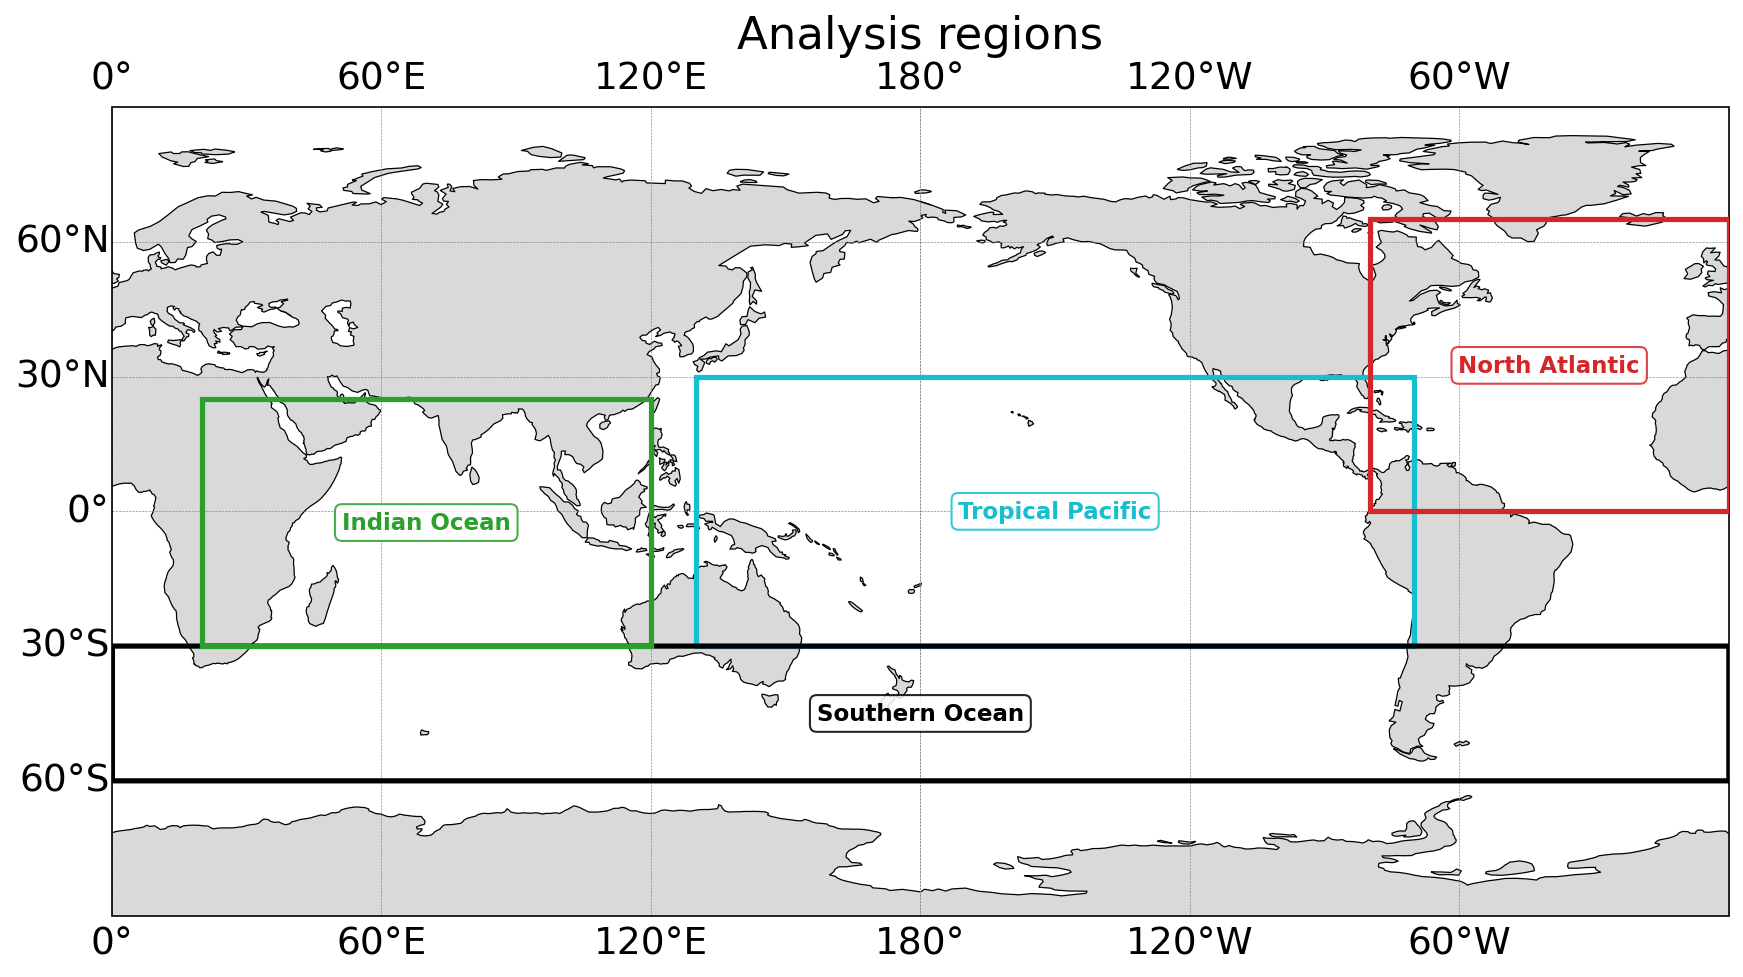

In [26]:
# Map of the analysis regions (no variable plotted -- just the region boxes,
# for reference before the profile/RMSE figures below). Regions are simple
# lon/lat rectangles, so central_longitude=180 puts the map seam over the
# Atlantic, away from every region (including Tropical Pacific, which spans
# the 180 deg meridian and would otherwise need to be split in two).
fig = plt.figure(figsize=(14, 7), dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor='0.85', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.3, color='gray')

for region, box in REGIONS.items():
    if box is None:                       # 'Global' = whole domain, no box
        continue
    s, n, w, e = box
    color = REGION_COLORS[region]
    rect = mpatches.Rectangle((w, s), e - w, n - s, linewidth=2.5,
                              edgecolor=color, facecolor='none',
                              transform=ccrs.PlateCarree(), zorder=5)
    ax.add_patch(rect)
    latc, lonc = 0.5 * (s + n), 0.5 * (w + e)
    ax.text(lonc, latc, region, color=color, fontsize=11, fontweight='bold',
           ha='center', va='center', transform=ccrs.PlateCarree(),
           bbox=dict(boxstyle='round', fc='white', ec=color, alpha=0.85), zorder=6)

ax.set_title('Analysis regions')
plt.show()


# 4. RMSE vs depth, by region

Area-weighted RMSE (model vs. WOA-2018) as a function of depth, for
temperature, salinity and $\sigma_2$. One figure per variable; one row per
region, with the Coupled and Forced panels placed side by side within that
row.


In [48]:
def plot_region_rmse(var, long_name, unit):
    # 5x2 grid (rows = region, columns = Coupled/Forced), same layout as
    # the bias profile figure above. A single shared legend sits below
    # the whole figure.
    biases = {name: bias_field(exps[name], var) for name in exp_names}

    fig, axes = plt.subplots(len(REGION_NAMES), 2, figsize=(14, 4.5 * len(REGION_NAMES)),
                             dpi=150, sharex=True)
    handles, labels = None, None
    for row, region in enumerate(REGION_NAMES):
        for col, (regime, names) in enumerate([('Coupled', coupled_names),
                                               ('Forced', forced_names)]):
            ax = axes[row, col]
            for name in names:
                rmse = region_rmse_profile(exps[name], region, biases[name])
                rmse.plot(ax=ax, y='z_l', color=PARAM_COLORS[LABELS[name]], lw=3,
                         label=LABELS[name])
            _set_depth_axis(ax)
            ax.set_title(f'{region}: {regime}')
            ax.set_xlabel(f'RMSE [{unit}]' if row == len(REGION_NAMES) - 1 else '')
            ax.set_ylabel('Depth [m]' if col == 0 else '')
            ax.grid(True, alpha=0.3)
            if col==0:
                ax.legend()
    fig.suptitle(f'{long_name} RMSE vs WOA-2018, by region and depth', fontsize=22)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

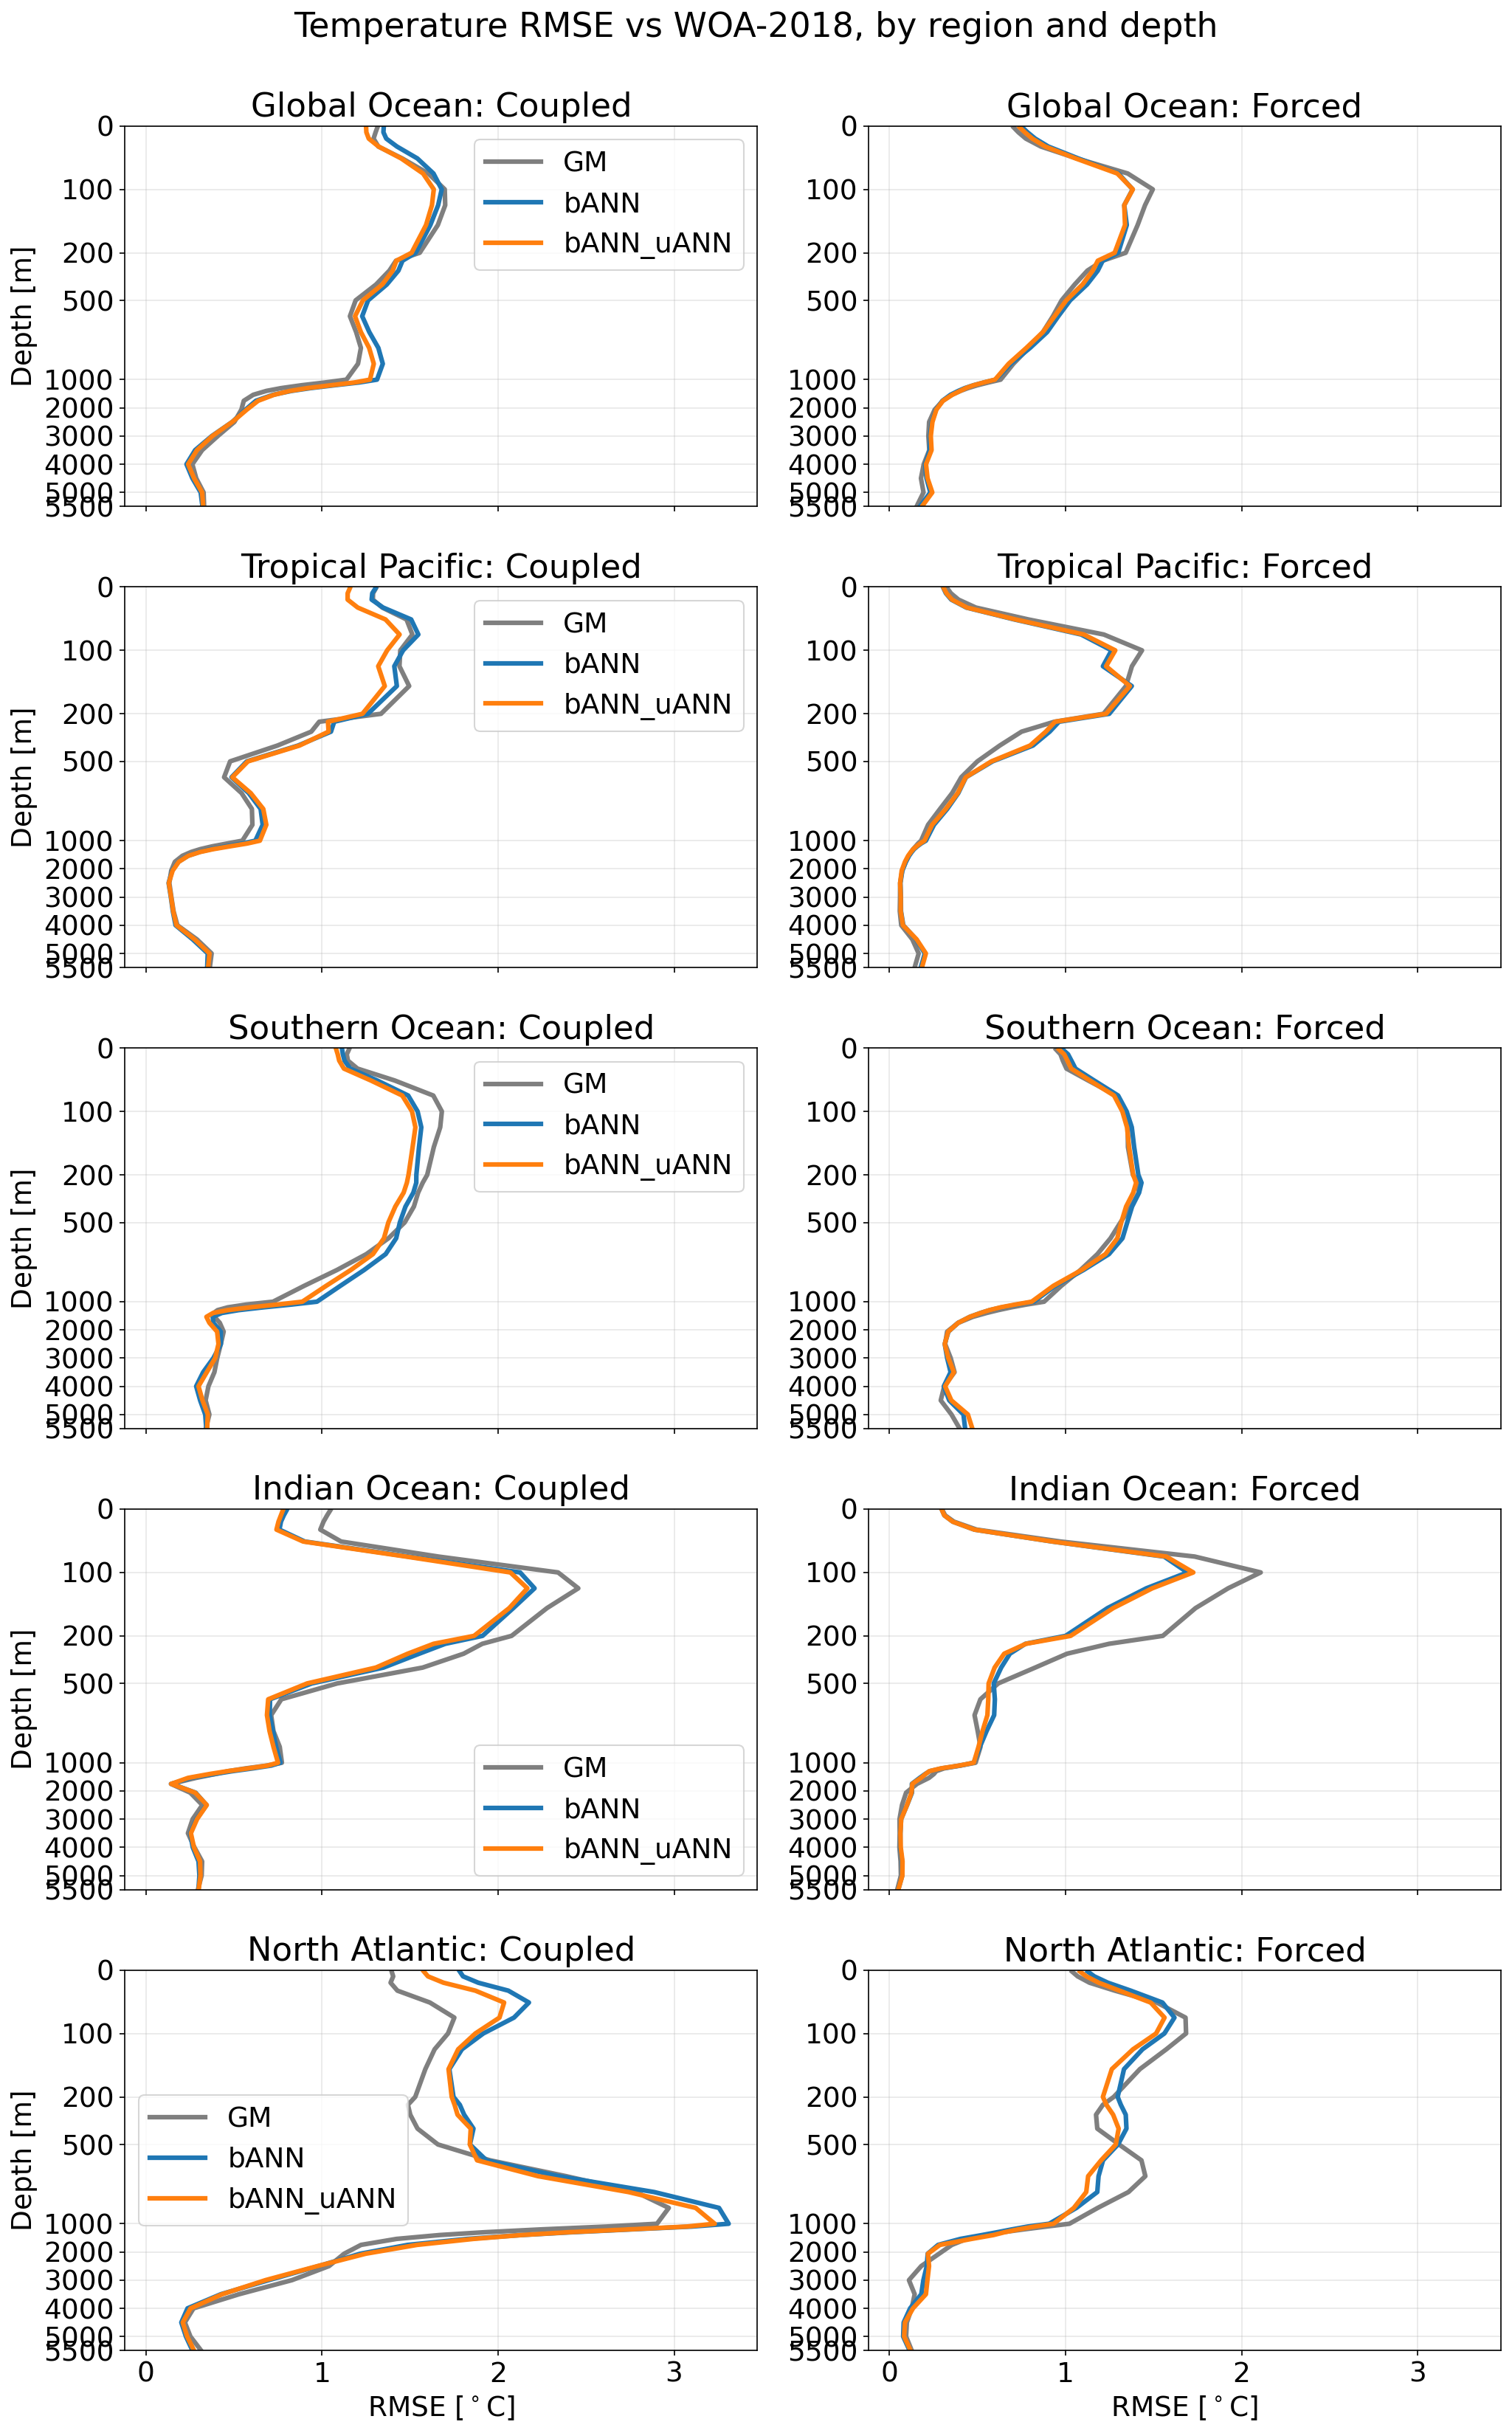

In [49]:
for var, long_name, unit in VARIABLES[0:1]:
    plot_region_rmse(var, long_name, unit)

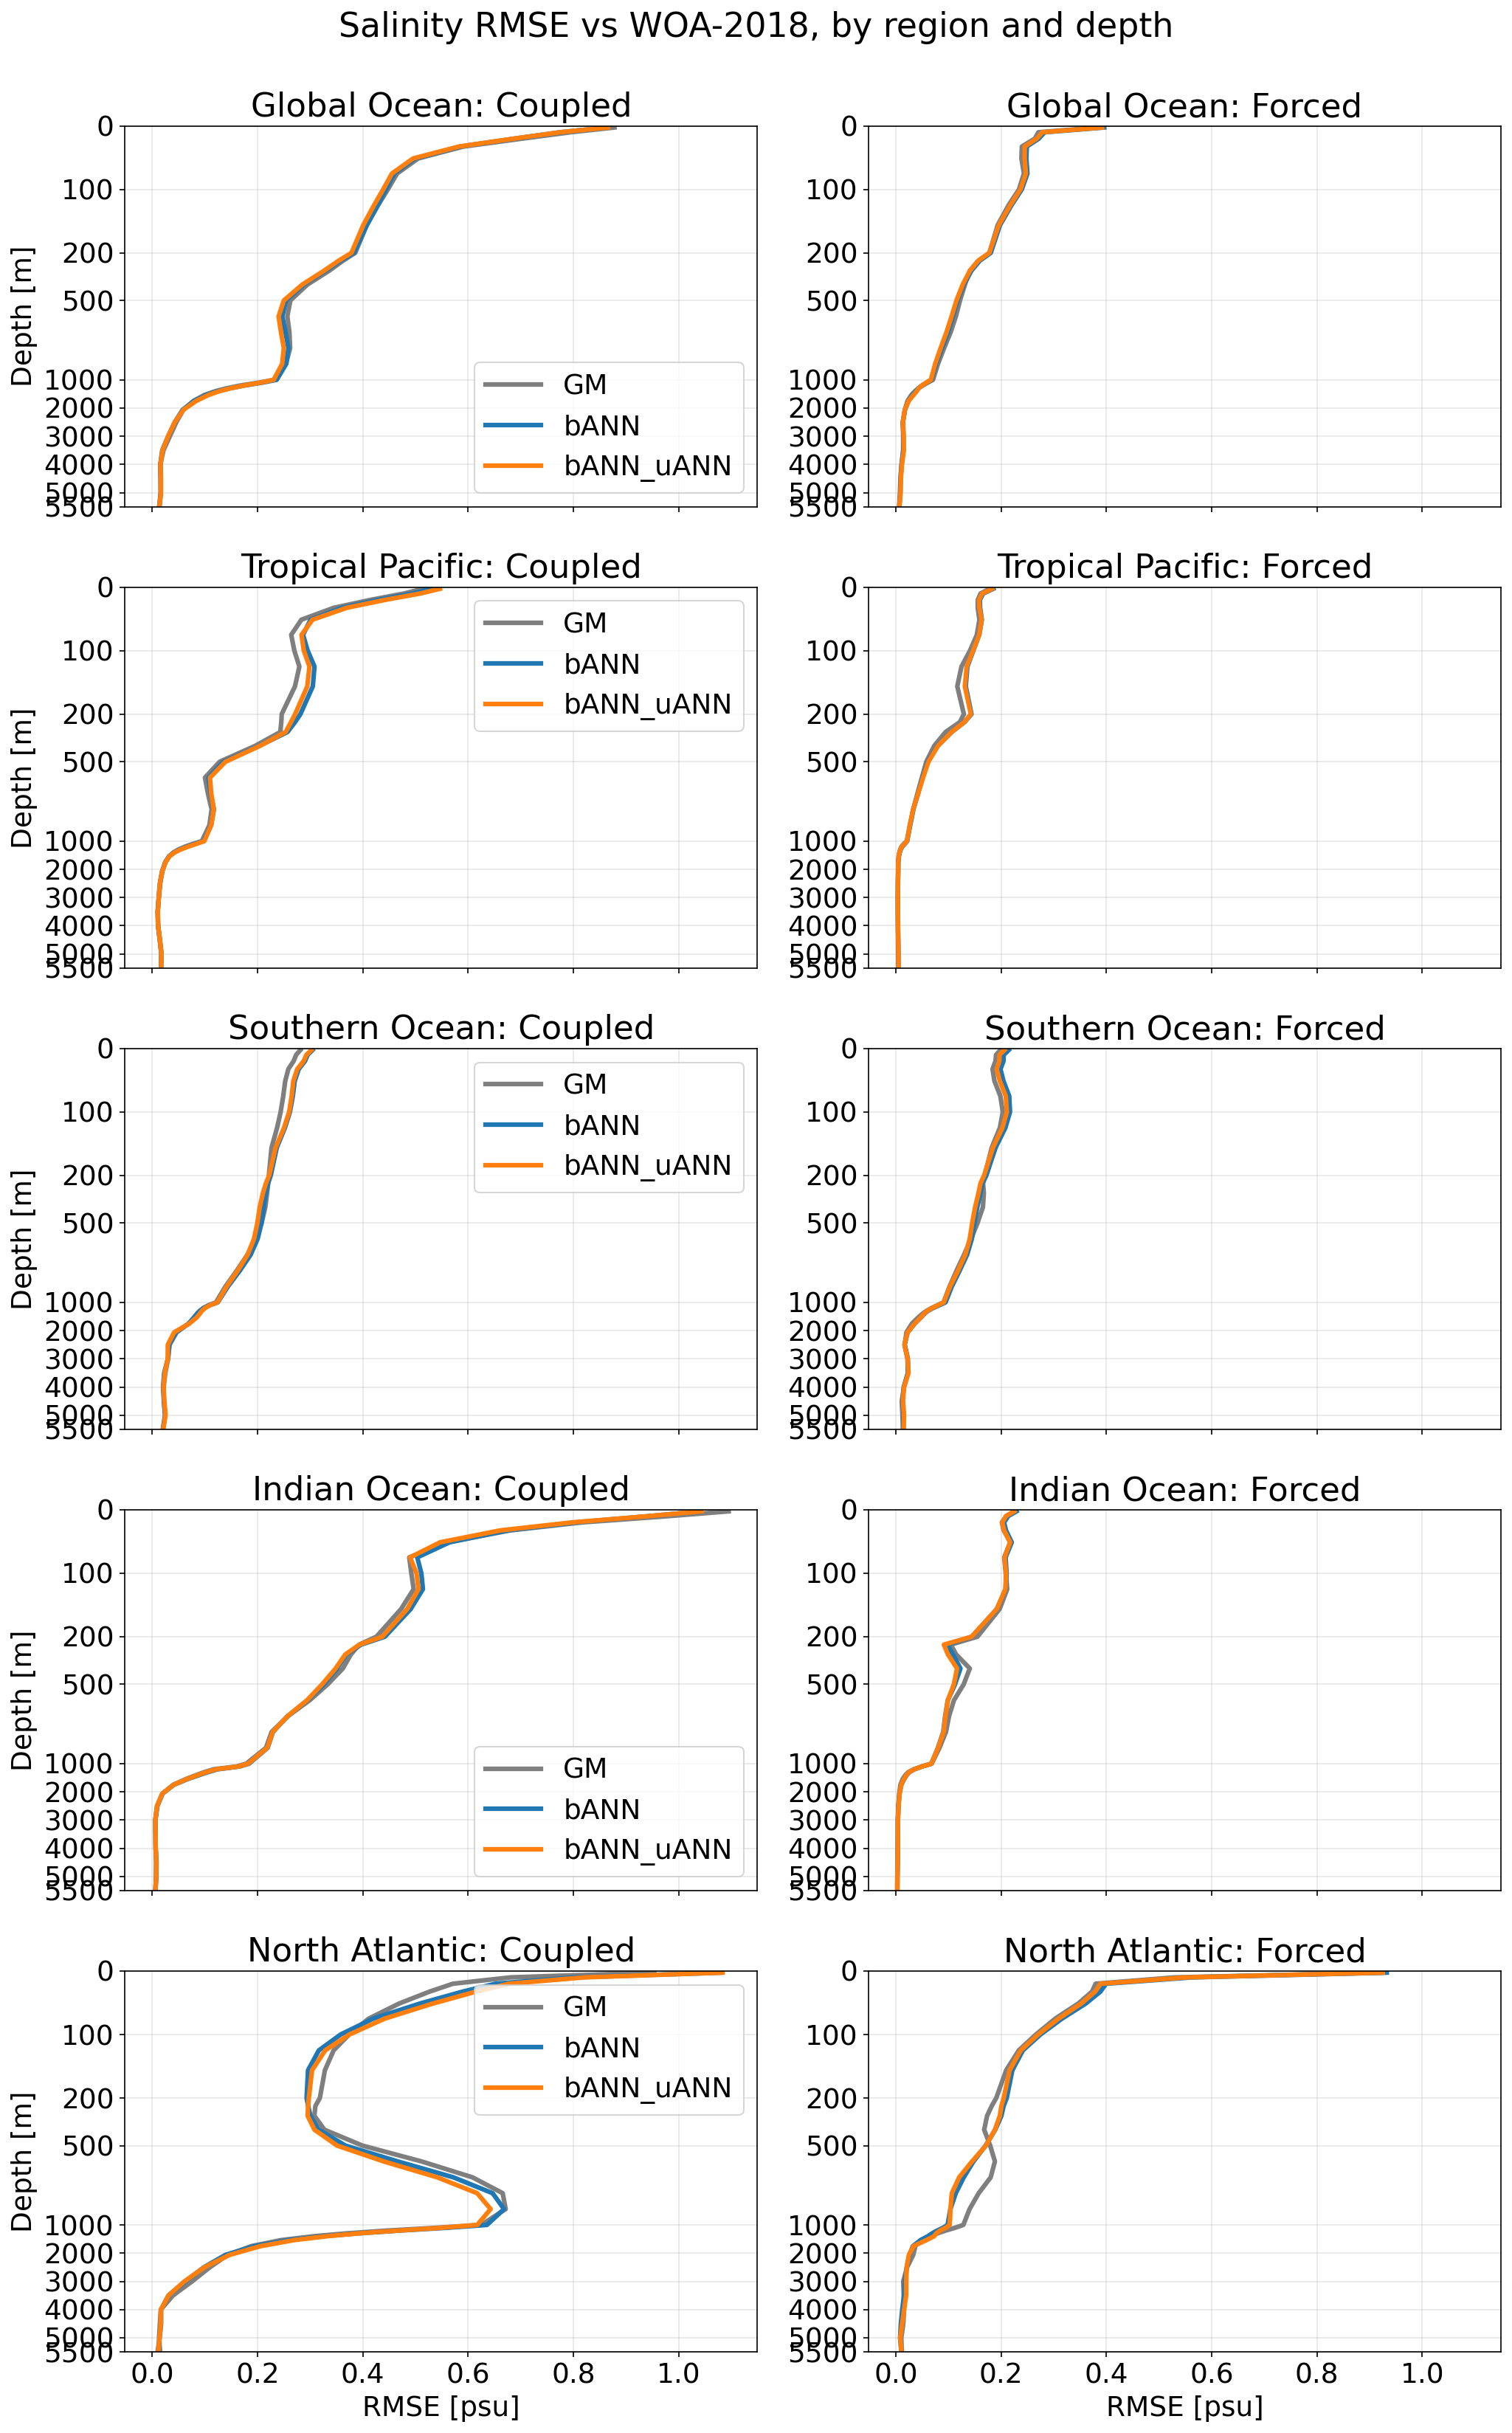

In [50]:
for var, long_name, unit in VARIABLES[1:2]:
    plot_region_rmse(var, long_name, unit)

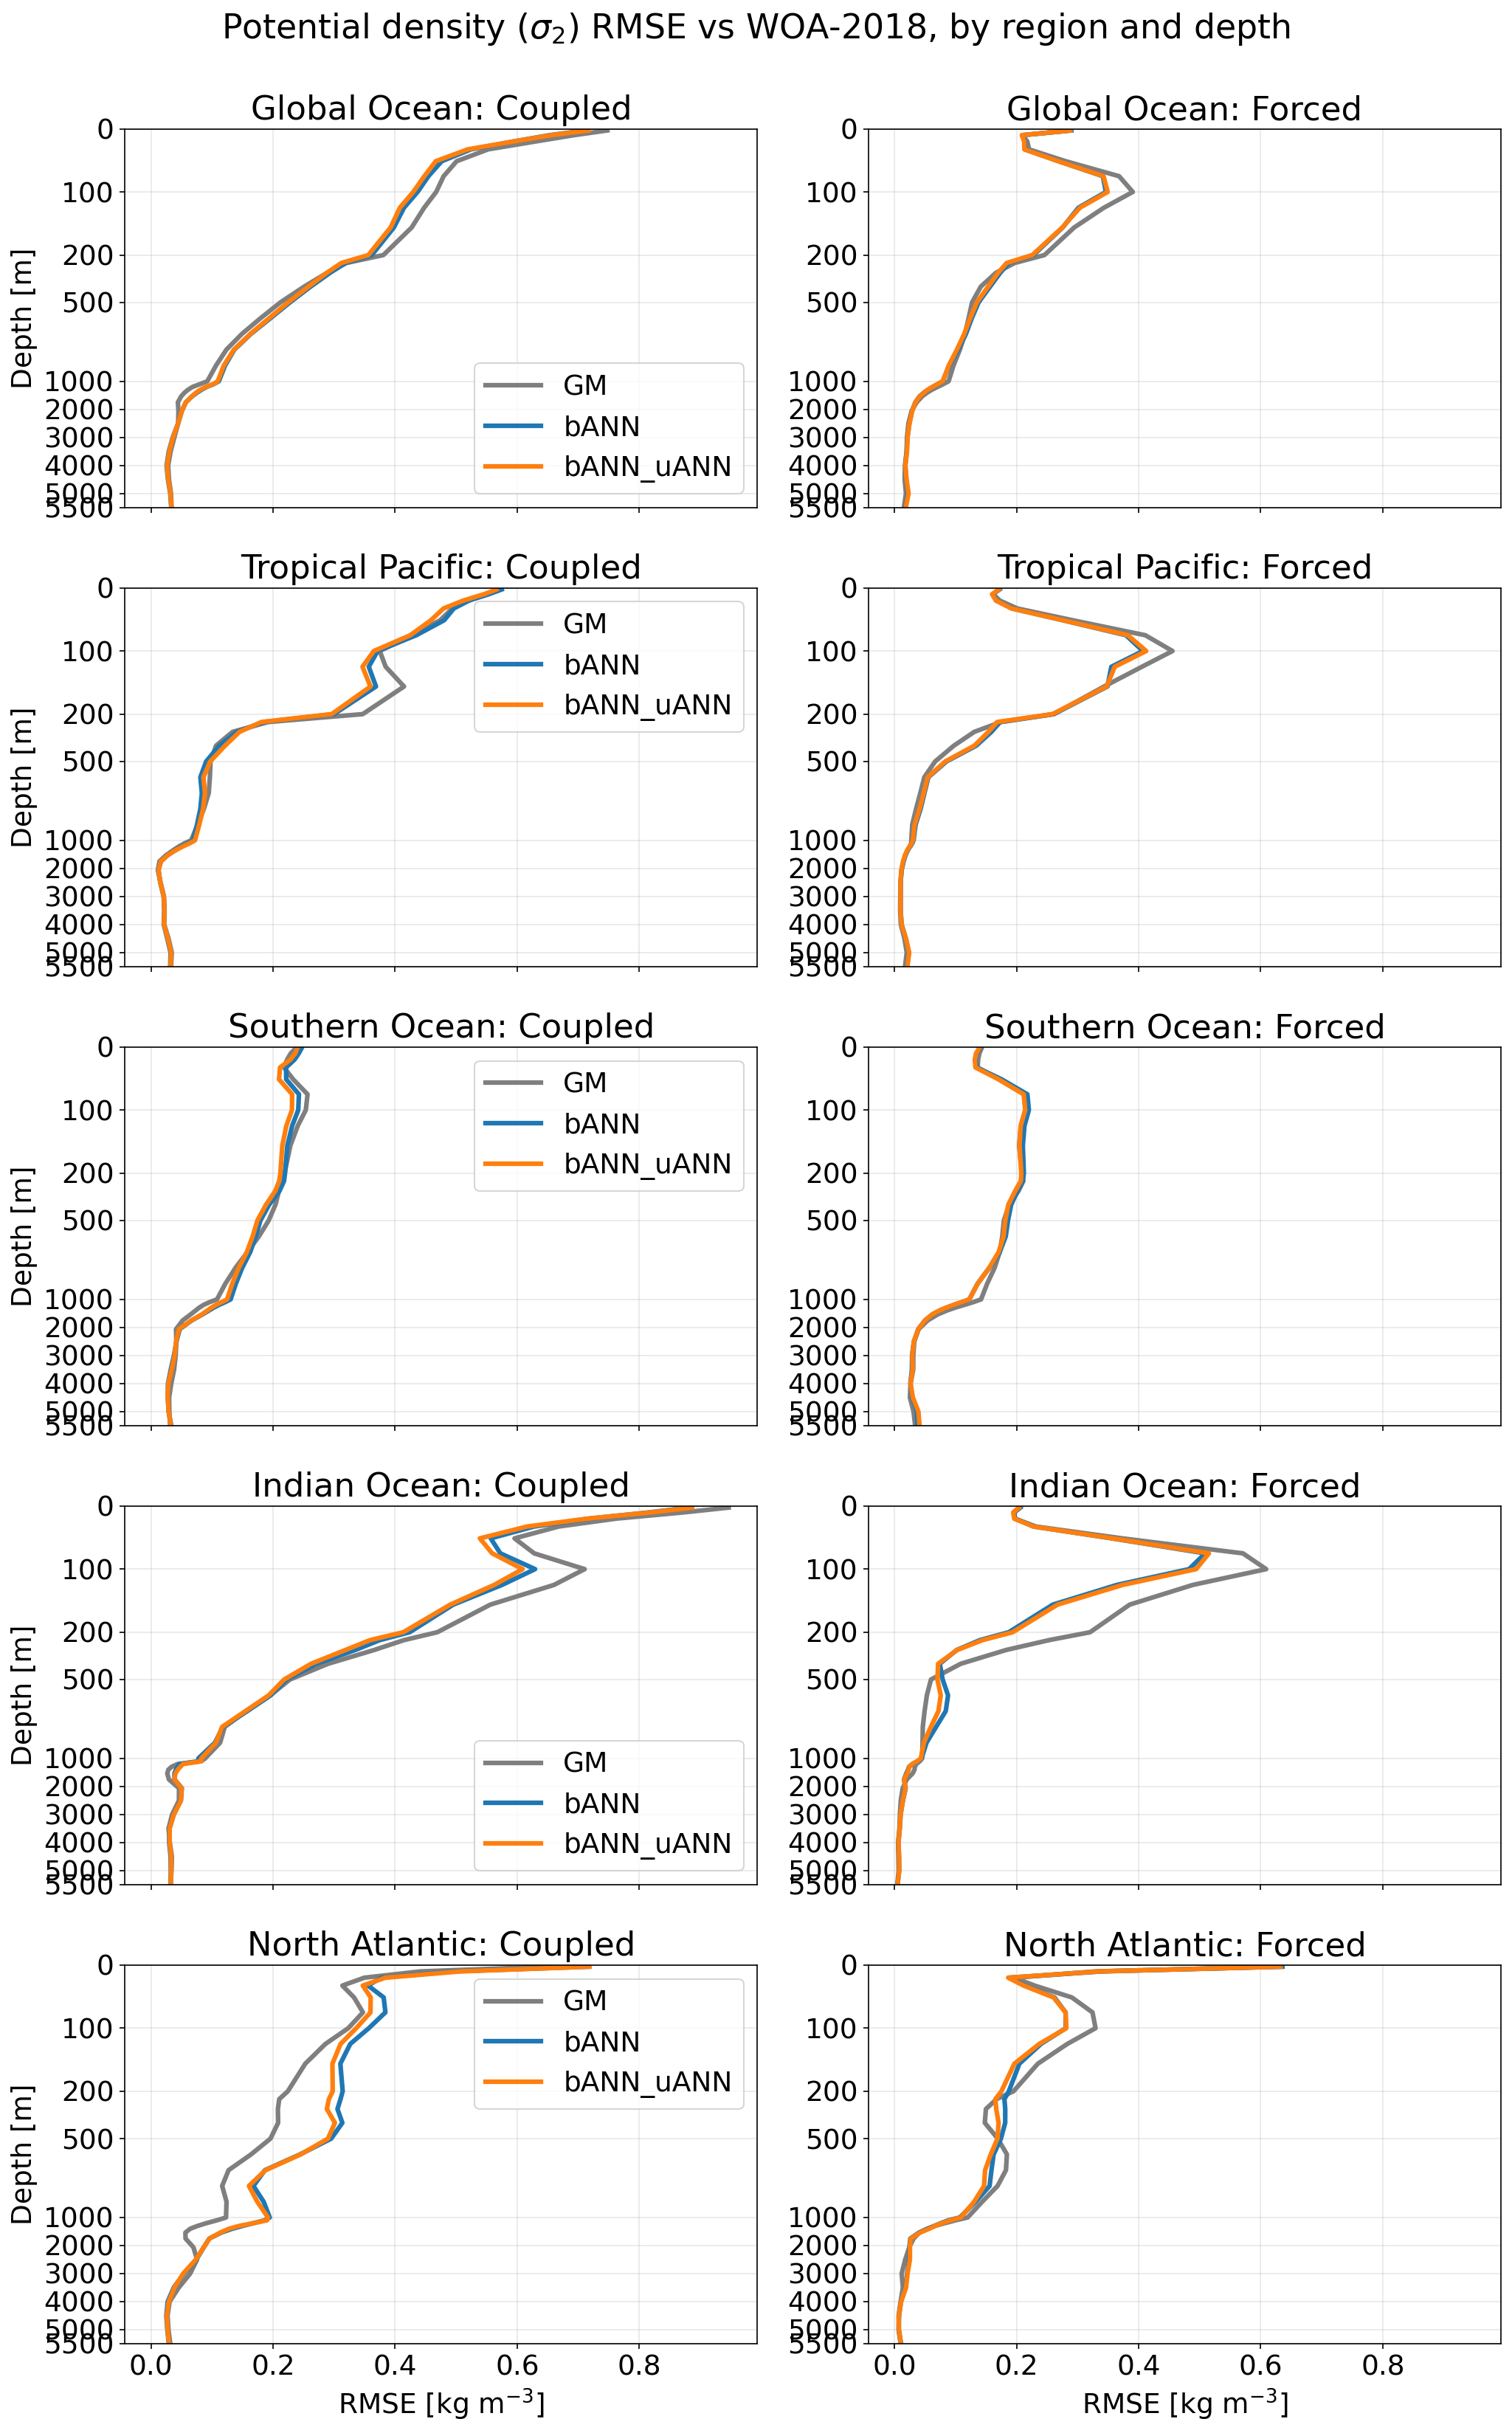

In [51]:
for var, long_name, unit in VARIABLES[2:3]:
    plot_region_rmse(var, long_name, unit)